**importing the libararies and Data Model:**

In [23]:
import pandas as pd
from pyod.models.iforest import IForest 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

**Feature engineering was Done heavily** because the Isolation Forest heavily relies on how good the feature is.  
**seconds_since_signup** = difference between purchase time and the signup time.  
**device_count** = normal users have 1 account per device where fraudsters has many.  
**ip_count** = count how many times the device appears in the whole data set.

In [16]:
df = pd.read_csv("Fraud_Data.csv")

df["signup_time"] = pd.to_datetime(df["signup_time"])
df["purchase_time"] = pd.to_datetime(df["purchase_time"])
df["seconds_since_signup"] = (df["purchase_time"] - df["signup_time"]).dt.total_seconds() 

df["device_count"] = df.groupby("device_id")["device_id"].transform("count")
df["ip_count"] = df.groupby("ip_address")["ip_address"].transform("count")

features = ["seconds_since_signup", "device_count", "ip_count", "purchase_value", "age"] # Features to put in the data model

1. 80% of data for training, and last 20% for testing. **(Train on Clean, Test on Dirty Technique)**  
**Filter to keep normal users** (is_fraud == 0)

In [17]:
index = int(len(df) * 0.8)
train_df = df.iloc[:index]
X_train = train_df[train_df["is_fraud"] == 0][features]

 2. **Test Set**: Use the rest (contains both normal and fraud)

In [18]:
test_df = df.iloc[index:].copy()
X_test = test_df[features]

3. **Train The Model**

In [19]:
print("Training Isolation Forest...")
model = IForest(contamination=0.1, random_state=42) 
#contamination is a percentage where we think how much the data have anamelies. (in this case we think the data has 10% frauds)
model.fit(X_train)

Training Isolation Forest...


,n_estimators,100
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,1
,behaviour,'old'
,random_state,42
,verbose,0


4. **Test the Model**

In [20]:
test_df["predicted_fraud"] = model.predict(X_test)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


5. **results** : 


result matrix:


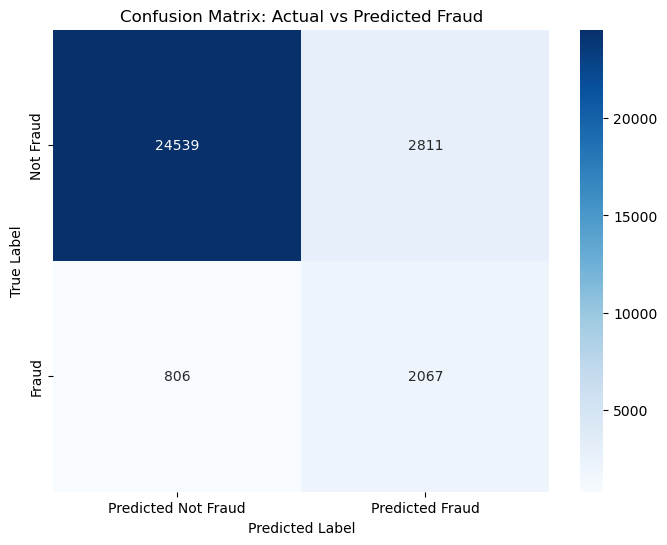

In [21]:
print("\nresult matrix:")
cross = pd.crosstab(
    test_df["is_fraud"], 
    test_df["predicted_fraud"],
    rownames=['Actual'], 
    colnames=['Predicted']
)

cross.index = ['Not Fraud', 'Fraud']
cross.columns = ['Predicted Not Fraud', 'Predicted Fraud']
plt.figure(figsize=(8, 6))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix: Actual vs Predicted Fraud')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [24]:
print(classification_report(test_df["is_fraud"], test_df["predicted_fraud"]))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93     27350
           1       0.42      0.72      0.53      2873

    accuracy                           0.88     30223
   macro avg       0.70      0.81      0.73     30223
weighted avg       0.92      0.88      0.89     30223



-the percentage of precision (True positives) is about **72%** which is **good in general**.  
-but if we want to increase this percentage we can increase the **contamination level** but this will produce more false positives.  
-but more false positives (normal people but detected as frauds) is better than having more frauds not detected.  
